# BPIC17 vs Simulated Log Comparison

This notebook compares the original BPIC 2017 event log against a simulated event log and quantifies how well simulation approximates reality.

It focuses on:
- activity distribution similarity
- trace variant overlap
- directly-follows (DFG) overlap
- case/event counts and throughput characteristics
- start/end activity alignment

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
if (cwd / "integration").exists():
    repo_root = cwd
elif (cwd.parent / "integration").exists():
    repo_root = cwd.parent
else:
    repo_root = cwd

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from integration.SimulationBenchmark import SimulationBenchmark

print("Repo root:", repo_root)

Repo root: D:\Repos\process-simulation-engine-1


In [ ]:
# Configure paths
ORIGINAL_LOG_PATH = repo_root / "Dataset" / "BPI Challenge 2017.xes"
SIMULATED_LOG_PATH = repo_root / "integration" / "output" / "full_balanced" /"simulated_log.csv"

print("Original log:", ORIGINAL_LOG_PATH)
print("Simulated log:", SIMULATED_LOG_PATH)

if not ORIGINAL_LOG_PATH.exists():
    raise FileNotFoundError(f"Original log not found: {ORIGINAL_LOG_PATH}")
if not SIMULATED_LOG_PATH.exists():
    raise FileNotFoundError(f"Simulated log not found: {SIMULATED_LOG_PATH}")

Original log: D:\Repos\process-simulation-engine-1\Dataset\BPI Challenge 2017.xes
Simulated log: D:\Repos\process-simulation-engine-1\integration\output\output_full_lifecycle\simulated_log.csv


In [3]:
# Build benchmark (set filter_lifecycle_complete=True if you want complete-only comparison)
benchmark = SimulationBenchmark(
    original_log=str(ORIGINAL_LOG_PATH),
    simulated_log=str(SIMULATED_LOG_PATH),
    filter_lifecycle_complete=False,
)

results = benchmark.compute_all_metrics()
print("Computed benchmark sections:", list(results.keys()))

Loading original log from D:\Repos\process-simulation-engine-1\Dataset\BPI Challenge 2017.xes...
Loading simulated log from D:\Repos\process-simulation-engine-1\integration\output\output_full_lifecycle\simulated_log.csv...
Computing benchmark metrics...
  - Basic statistics...
  - Events per case...
  - Case throughput time...
  - Case arrivals...
  - Case completions...
  - Control flow (DFG)...
  - Trace variants...
  - Start/End activities...
  - Activity durations...
  - Overall activity distribution...
  - Simple similarity metrics...
  - Resource statistics...
Benchmark computation complete!
Computed benchmark sections: ['basic_stats', 'events_per_case', 'throughput_time', 'arrivals', 'completions', 'dfg_top', 'dfg_comparison', 'variants_top', 'variants_comparison', 'start_activities', 'end_activities', 'activity_durations', 'activity_distribution', 'simple_metrics', 'resource_stats', 'activity_resource']


In [4]:
# Quick headline summary table
results["simple_metrics"]

,Metric,Value,Percentage
0,Activity Overlap,25 / 26 activities,96.153846
1,Activity Jaccard Similarity,0.9615,96.153846
2,Trace Variant Overlap,5 / 15930 variants,0.031387
3,Trace Variant Jaccard Similarity,0.0003,0.031215
4,Top 10 Variant Overlap,1 / 10 variants,10.000000
5,DFG Edge Overlap,75 / 178 edges,42.134831
6,DFG Edge Jaccard Similarity,0.3866,38.659794
7,Top 20 DFG Edge Overlap,14 / 20 edges,70.000000
8,Case Count Ratio,100 / 31509 cases,0.317370
9,Event Count Ratio,7027 / 1202267 events,0.584479


In [5]:
# Core descriptive tables
results["basic_stats"]

,Log,Number of Events,Number of Cases,Number of Unique Activities,Number of Unique Resources
0,Original,1202267,31509,26,149
1,Simulated,7027,100,25,121


In [6]:
results["events_per_case"]

,Log,Mean,Median,P90,Max
0,Original,38.156305,35.0,60.0,180
1,Simulated,70.270000,44.5,143.9,500


In [7]:
results["throughput_time"]

,Log,Mean (hours),Median (hours),P75 (hours),P90 (hours),P95 (hours),Max (hours)
0,Original,525.590534,458.105741,755.897485,841.317475,1020.504708,6865.738515
1,Simulated,1028.624568,702.376296,1275.509949,1941.966457,2278.232096,8777.960740


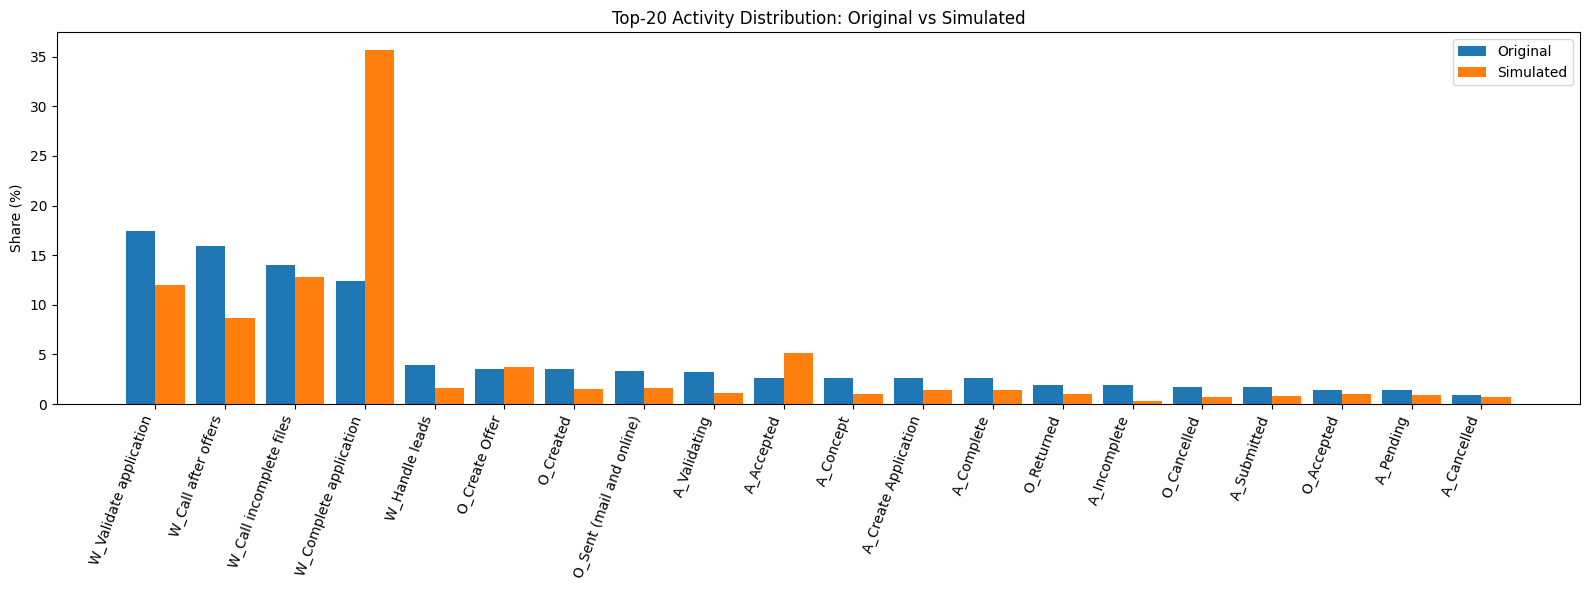

,Activity,Original Share (%),Simulated Share (%),Share Difference (%)
1,W_Validate application,17.425081,12.039277,-5.385804
13,W_Call after offers,15.894306,8.623879,-7.270427
19,W_Call incomplete files,14.017602,12.779280,-1.238322
16,W_Complete application,12.384936,35.662445,23.277509
15,W_Handle leads,3.931240,1.593852,-2.337388
12,O_Create Offer,3.576161,3.685783,0.109623
6,O_Created,3.576161,1.494237,-2.081924
14,O_Sent (mail and online),3.302677,1.622314,-1.680363
2,A_Validating,3.228567,1.081543,-2.147025
9,A_Accepted,2.620799,5.137327,2.516529


In [8]:
# Activity distribution comparison (top-20 by original frequency)
activity_cmp = results["activity_distribution"].copy()
activity_top20 = activity_cmp.sort_values("Original Count", ascending=False).head(20)

x = np.arange(len(activity_top20))
width = 0.42

plt.figure(figsize=(16, 6))
plt.bar(x - width/2, activity_top20["Original Share (%)"], width=width, label="Original")
plt.bar(x + width/2, activity_top20["Simulated Share (%)"], width=width, label="Simulated")
plt.xticks(x, activity_top20["Activity"], rotation=70, ha="right")
plt.ylabel("Share (%)")
plt.title("Top-20 Activity Distribution: Original vs Simulated")
plt.legend()
plt.tight_layout()
plt.show()

activity_top20[["Activity", "Original Share (%)", "Simulated Share (%)", "Share Difference (%)"]]

In [9]:
# Trace variant alignment
variants_cmp = results["variants_comparison"].copy()
variants_cmp.head(20)

,Variant,Original Count,Original Share (%),Original Rank,Simulated Count,Simulated Share (%),Simulated Rank
7,A_Create Application → A_Submitted → W_Handle ...,1056,3.351423,1.0,0,0.0,NaN
35,A_Create Application → W_Complete application ...,1021,3.240344,2.0,0,0.0,NaN
4,A_Create Application → A_Submitted → W_Handle ...,734,2.329493,3.0,2,2.0,3.0
11,A_Create Application → A_Submitted → W_Handle ...,451,1.431337,4.0,0,0.0,NaN
10,A_Create Application → A_Submitted → W_Handle ...,332,1.053667,5.0,0,0.0,NaN
23,A_Create Application → A_Submitted → W_Handle ...,298,0.945762,6.0,1,1.0,4.0
37,A_Create Application → W_Complete application ...,278,0.882288,7.0,0,0.0,NaN
6,A_Create Application → A_Submitted → W_Handle ...,244,0.774382,8.0,0,0.0,NaN
26,A_Create Application → A_Submitted → W_Handle ...,212,0.672824,9.0,0,0.0,NaN
32,A_Create Application → A_Submitted → W_Handle ...,204,0.647434,10.0,0,0.0,NaN


In [10]:
# DFG edge alignment
results["dfg_comparison"].head(25)

,From,To,Original Count,Original Share (%),Original Rank,Simulated Count,Simulated Share (%),Simulated Rank
22,W_Validate application,W_Validate application,115590,9.873091,1.0,609,8.791685,3
13,W_Call after offers,W_Call after offers,115569,9.871297,2.0,370,5.341418,5
5,W_Call incomplete files,W_Call incomplete files,113918,9.730277,3.0,816,11.779991,2
16,W_Complete application,W_Complete application,64695,5.525907,4.0,1929,27.847553,1
21,O_Create Offer,O_Created,42995,3.672407,5.0,105,1.515808,10
18,W_Validate application,A_Validating,38816,3.315459,6.0,76,1.097156,17
23,O_Created,O_Sent (mail and online),35604,3.041107,7.0,96,1.385881,15
6,W_Complete application,W_Call after offers,31362,2.678777,8.0,104,1.501371,12
9,W_Call after offers,A_Complete,31362,2.678777,8.0,98,1.414754,14
0,O_Sent (mail and online),W_Complete application,30912,2.640341,10.0,101,1.458063,13


In [11]:
# Start and end activities
print("Start activities")
display(results["start_activities"].head(20))

print("End activities")
display(results["end_activities"].head(20))

Start activities


,Activity,Original Count,Original Share (%),Simulated Count,Simulated Share (%)
0,A_Create Application,31509,100.0,100,100.0


End activities


,Activity,Original Count,Original Share (%),Simulated Count,Simulated Share (%)
2,W_Validate application,12662,40.185344,48,48.0
9,W_Call after offers,9457,30.013647,30,30.0
3,W_Call incomplete files,4676,14.840204,8,8.0
10,O_Cancelled,4436,14.078517,13,13.0
1,W_Complete application,144,0.457012,0,0.0
0,W_Assess potential fraud,102,0.323717,1,1.0
8,O_Sent (mail and online),15,0.047605,0,0.0
5,O_Sent (online only),8,0.025390,0,0.0
11,W_Shortened completion,5,0.015868,0,0.0
7,W_Personal Loan collection,2,0.006347,0,0.0


## Interpreting Results

Use these signals as a quick approximation scorecard:
- **Activity Jaccard Similarity**: higher means better activity coverage match.
- **Trace Variant Overlap**: higher means generated process paths resemble original paths.
- **DFG Edge Jaccard Similarity**: higher means local control-flow transitions are preserved.
- **Count Ratios (cases/events)** near 100%: simulation scale matches source log.
- **Share Difference (%)** near 0 for frequent activities: good distribution calibration.

Optional: export all benchmark tables to Excel in the next cell.

In [12]:
# Optional export
OUT_XLSX = repo_root / "integration" / "output" / "bpic17_vs_simulation_benchmark.xlsx"
benchmark.export_results(str(OUT_XLSX))
print("Exported:", OUT_XLSX)

Results exported to D:\Repos\process-simulation-engine-1\integration\output\bpic17_vs_simulation_benchmark.xlsx
Exported: D:\Repos\process-simulation-engine-1\integration\output\bpic17_vs_simulation_benchmark.xlsx
